In [425]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

%matplotlib inline

In [426]:
# Principal Component Analysis (PCA)

# Introduction

In [427]:
iris_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
df_iris = pd.read_csv(iris_url, names=['sepal length','sepal width','petal length','petal width','target'])

df_iris.head(5)

,sepal length,sepal width,petal length,petal width,target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


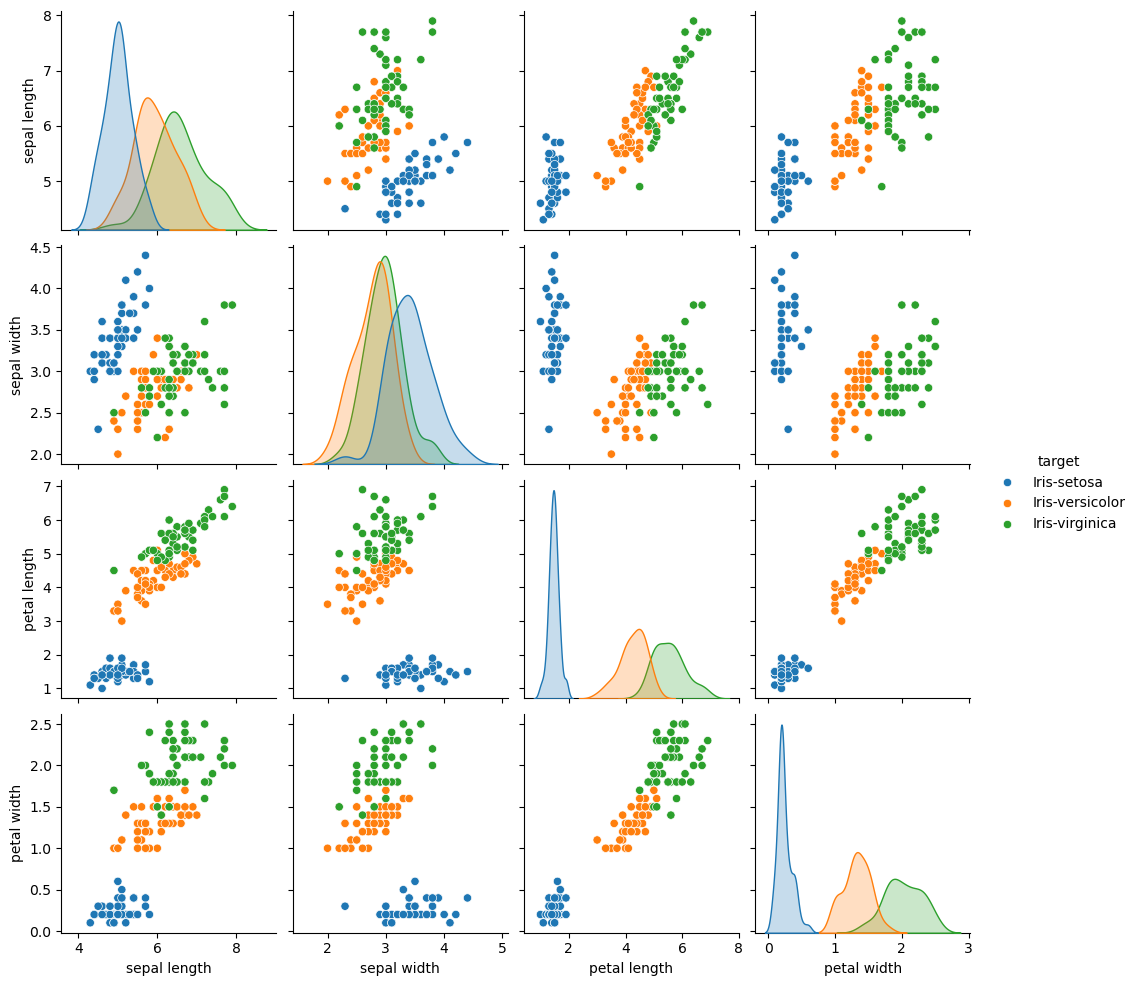

In [428]:
sns.pairplot(df_iris, hue='target')

In [429]:
# Petal length and petal width exhibit a strong linear correlation, as a straight line can closely approximate the distribution of the data points. 
# When one of these features increases, the other tends to increase as well, and vice versa.

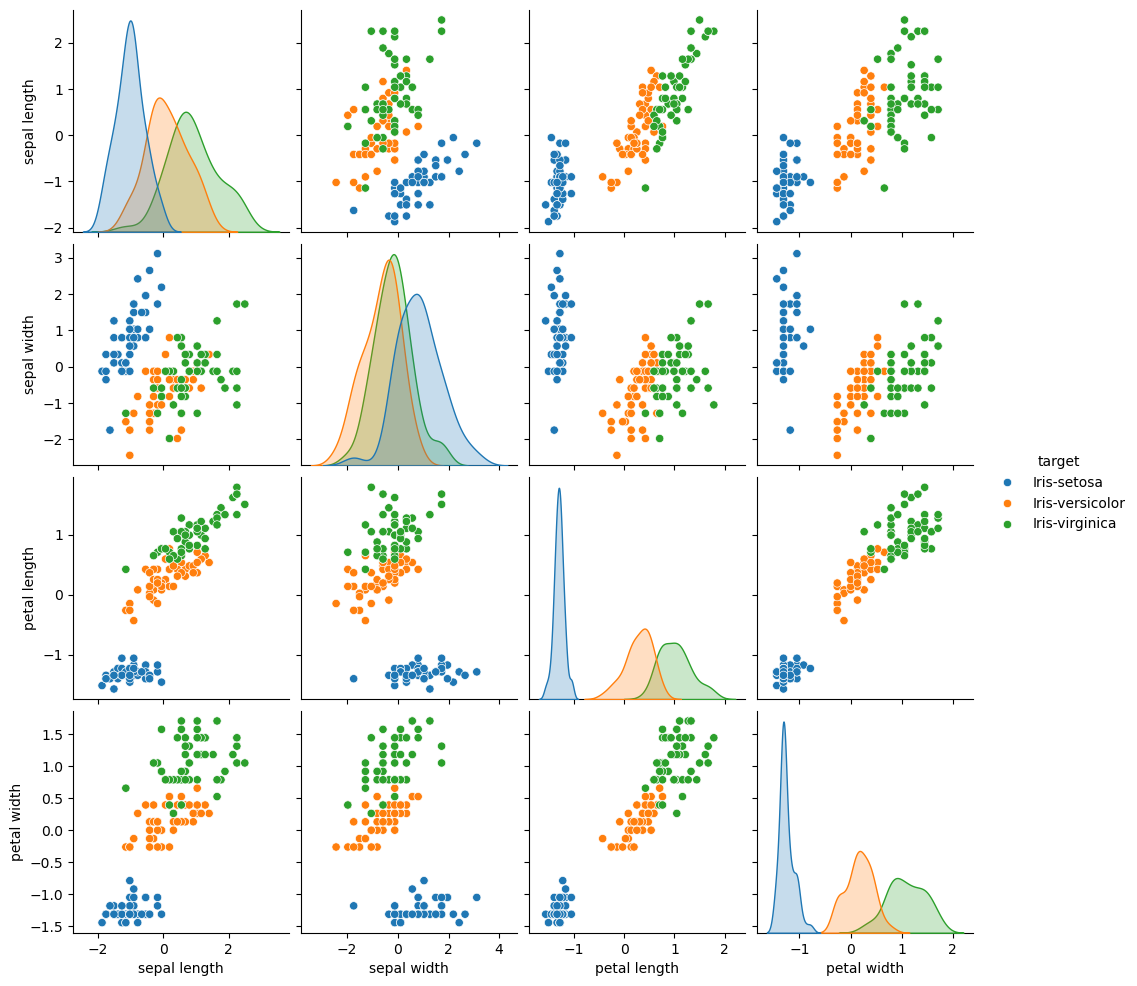

In [430]:
features_iris = ['sepal length', 'sepal width', 'petal length', 'petal width']
x_iris = df_iris.loc[:, features_iris].values

y_iris = df_iris.loc[:,['target']].values

x_iris = StandardScaler().fit_transform(x_iris)

df_iris_standarize = pd.DataFrame(data = x_iris, columns = features_iris)
df_iris_standarize['target'] = df_iris['target']

sns.pairplot(df_iris_standarize, hue='target')

In [431]:
pca_iris = PCA(n_components=2)

principal_components_iris = pca_iris.fit_transform(x_iris)
principal_df_iris = pd.DataFrame(data = principal_components_iris, columns = ['principal component 1', 'principal component 2'])

final_df_iris = pd.concat([principal_df_iris, df_iris[['target']]], axis = 1)
final_df_iris.head(15)

,principal component 1,principal component 2,target
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa
5,-2.070537,1.518549,Iris-setosa
6,-2.445711,0.074563,Iris-setosa
7,-2.233842,0.247614,Iris-setosa
8,-2.341958,-1.095146,Iris-setosa
9,-2.188676,-0.448629,Iris-setosa


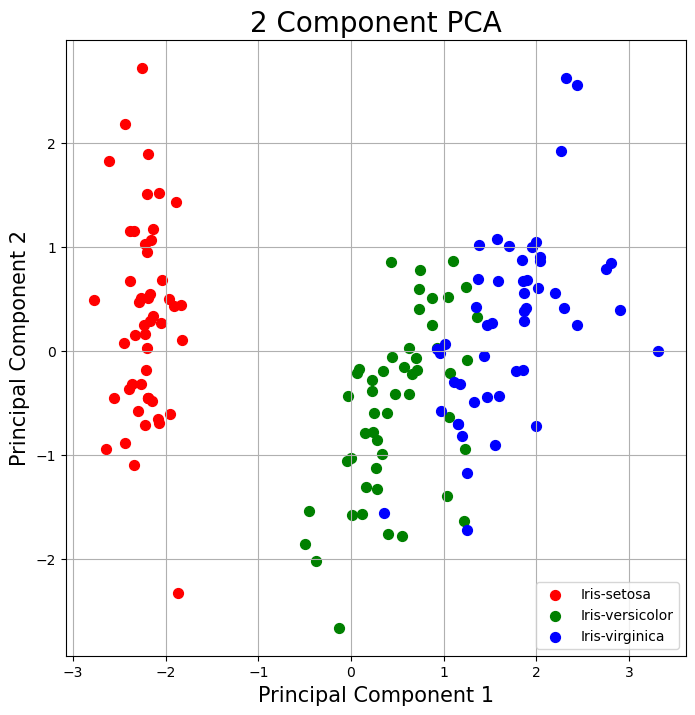

In [432]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1)
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('2 Component PCA', fontsize = 20)

iris_targets = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
colors = ['r', 'g', 'b']
for target, color in zip(iris_targets, colors):
    indices_to_keep = final_df_iris['target'] == target

    ax.scatter(
        final_df_iris.loc[indices_to_keep, 'principal component 1'],
        final_df_iris.loc[indices_to_keep, 'principal component 2'],
        c = color,
        s = 50
    )
#

ax.legend(iris_targets)
ax.grid()

In [433]:
pca_iris.explained_variance_ratio_

array([0.72770452, 0.23030523])

# Makemoons

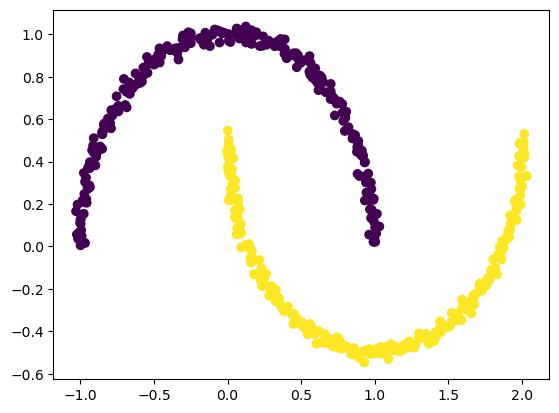

In [434]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples = 500, noise = 0.02, random_state = 417)

plt.scatter(X[:, 0], X[:, 1], c = y)
plt.show()

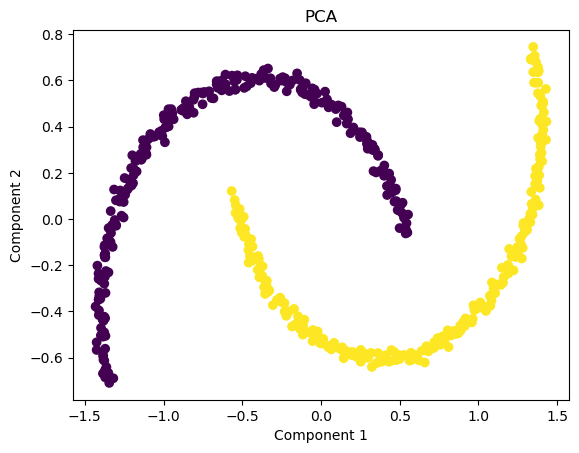

In [435]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

plt.title("PCA")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = y)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

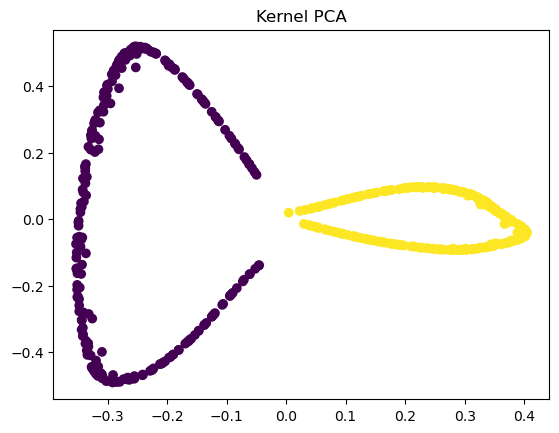

In [436]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(kernel ='rbf', gamma = 15)
X_kpca = kpca.fit_transform(X)

plt.title("Kernel PCA")
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c = y)
plt.show()

# Exercise 1: Breast Cancer

In [437]:
from sklearn.datasets import load_breast_cancer

breast_cancer_data = load_breast_cancer()
breast_cancer_df = pd.DataFrame(breast_cancer_data.data, columns=breast_cancer_data.feature_names)
breast_cancer_df['target'] = breast_cancer_data.target

In [438]:
breast_cancer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [439]:
breast_cancer_df.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [440]:
breast_cancer_df['target'] = pd.Categorical.from_codes(
    breast_cancer_df['target'],
    ['benign', 'malignant']
)

In [441]:
breast_cancer_df_corr = breast_cancer_df.corr(numeric_only=True)

<Axes: >

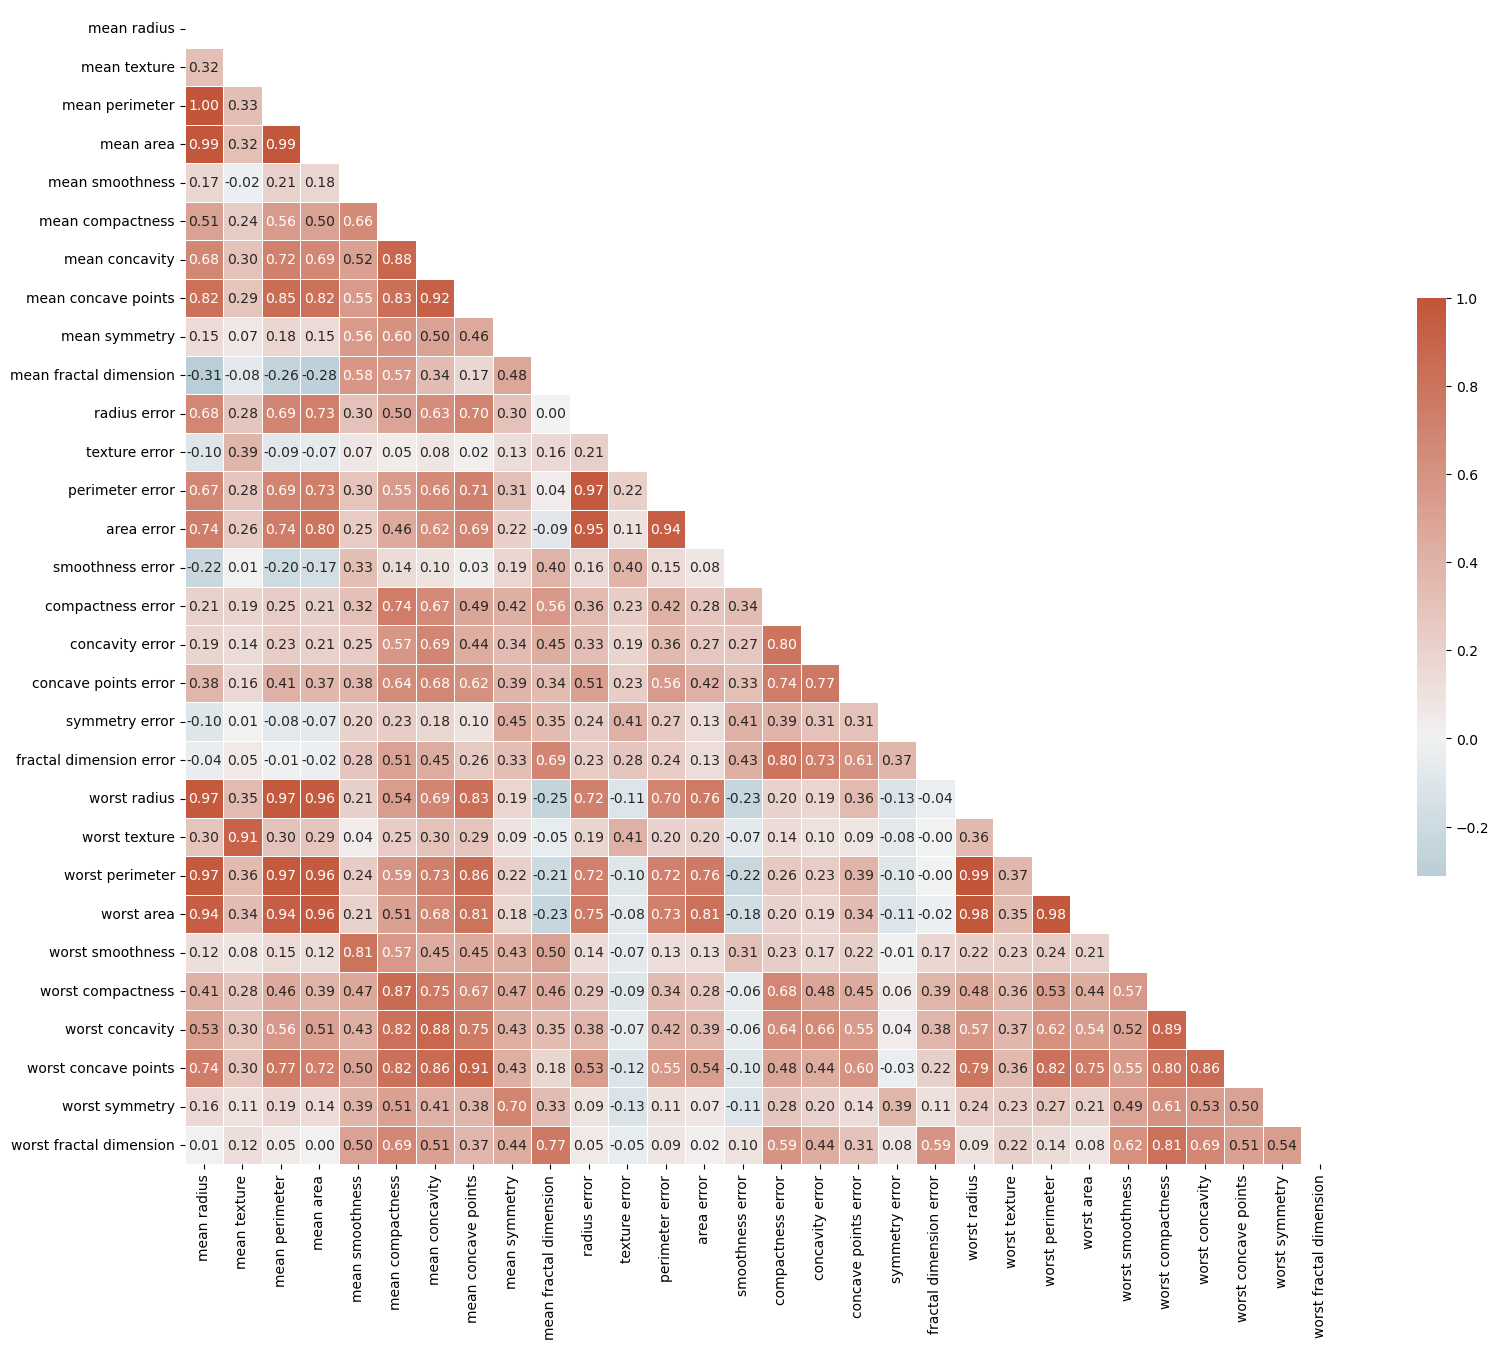

In [442]:
plt.figure(figsize=(20, 15))

mask = np.triu(np.ones_like(breast_cancer_df_corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(breast_cancer_df_corr, annot=True, mask=mask, cmap=cmap, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5}, fmt=".2f")

In [443]:
# Na podstawie powyższej macierzy korelacji widać, że wiele cech jest liniowo-skorelowana, co oznacza, że przed użyciem np. regresji liniowej, odpowiednie cechy powinny zostać usunięte.

In [444]:
breast_cancer_X = breast_cancer_df.drop(columns='target')
breast_cancer_y = breast_cancer_df['target']

In [445]:
breast_cancer_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

breast_cancer_X_transformed = breast_cancer_pca_pipeline.fit_transform(breast_cancer_X)

breast_cancer_df_transformed = pd.DataFrame(breast_cancer_X_transformed, columns=['PC1', 'PC2'])
breast_cancer_df_transformed = pd.concat([breast_cancer_df_transformed, breast_cancer_y], axis=1)

In [446]:
breast_cancer_df_transformed['target'].cat.categories

Index(['benign', 'malignant'], dtype='str')

In [447]:
def visualize_pca(
    df: pd.DataFrame,
    pc1: str = "PC1",
    pc2: str = "PC2",
    target_col: str = "target",
    title: str = "PCA 2D visualization"
):

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.set_xlabel("PC1", fontsize=12)
    ax.set_ylabel("PC2", fontsize=12)
    ax.set_title(title, fontsize=14)

    targets = df[target_col].cat.categories

    cmap = mpl.colormaps["tab10"]

    for i, target in enumerate(targets):
        mask = df[target_col] == target

        ax.scatter(
            df.loc[mask, pc1],
            df.loc[mask, pc2],
            color=cmap(i),
            s=40,
            label=str(target)
        )
    #

    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

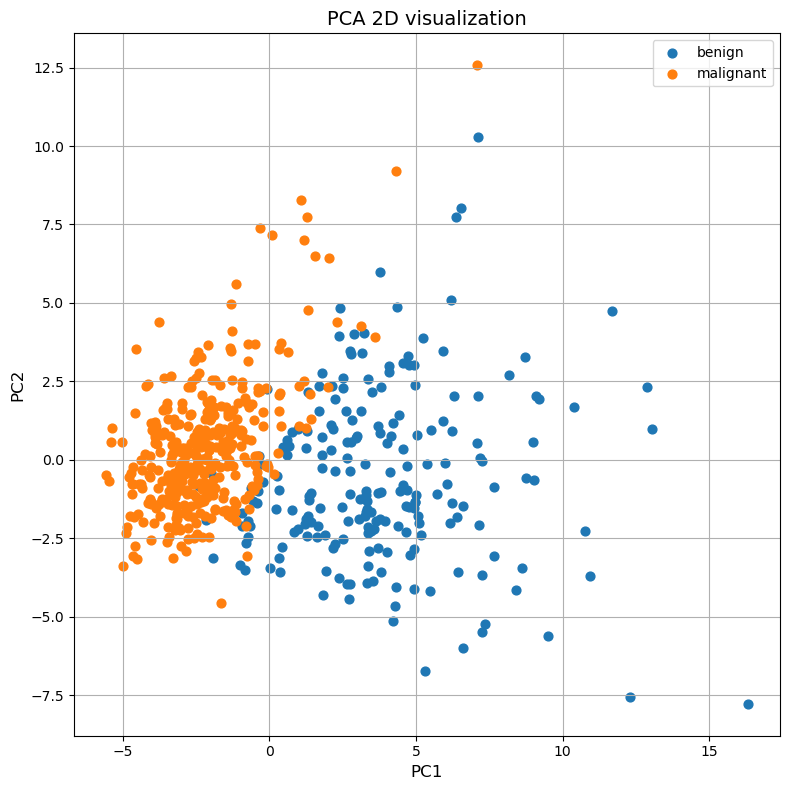

In [448]:
visualize_pca(breast_cancer_df_transformed)

In [449]:
breast_cancer_pca = breast_cancer_pca_pipeline.named_steps['pca']
breast_cancer_pca.explained_variance_ratio_

array([0.44272026, 0.18971182])

In [450]:
# Dodając do siebie otrzymane wariancje dostajemy około 0.63, więc nasze dwa komponenty zawierają około 63% informacji. Do samej wizualizacji 2D jest to w porządku,
# ale jako krok w procesie inżynierii cech, ten wynik jest dość mały. Należy zwiększyć liczbę komponentów.

In [451]:
breast_cancer_pca_pipeline.set_params(pca__n_components=15)
breast_cancer_X_transformed = breast_cancer_pca_pipeline.fit_transform(breast_cancer_X)

breast_cancer_df_transformed = pd.DataFrame(breast_cancer_X_transformed)
breast_cancer_df_transformed = pd.concat([breast_cancer_df_transformed, breast_cancer_y], axis=1)

In [452]:
breast_cancer_pca = breast_cancer_pca_pipeline.named_steps['pca']

explained_variance_full = breast_cancer_pca.explained_variance_ratio_
cumulative_variance_full = np.cumsum(explained_variance_full)

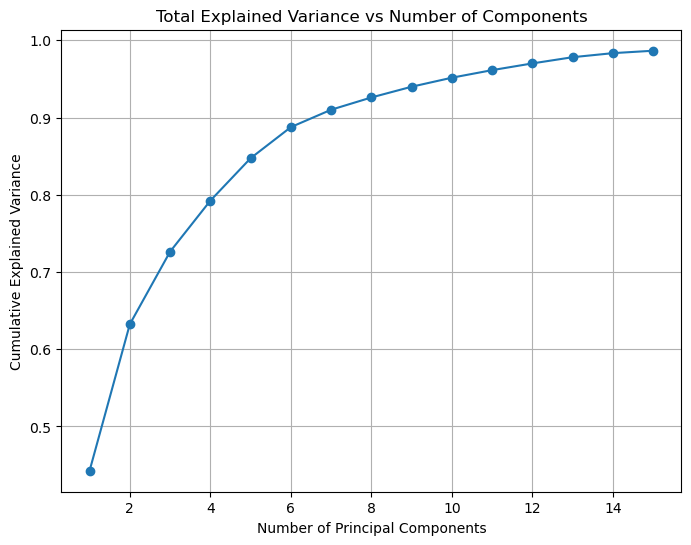

In [453]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(cumulative_variance_full) + 1),
    cumulative_variance_full,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Total Explained Variance vs Number of Components")
plt.grid(True)
plt.show()

In [454]:
# Przed użyciem RFE dane należy standaryzować.

# breast_cancer_X
# breast_cancer_y

In [455]:
breast_cancer_rfe_pipeline = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),
    (
        'rfe',
        RFE(
            estimator=LogisticRegression(n_jobs=-1),
            n_features_to_select=15
        )
    )
])

breast_cancer_X_transformed = breast_cancer_rfe_pipeline.fit_transform(breast_cancer_X, breast_cancer_y)

selected_columns = breast_cancer_X.columns[
    breast_cancer_rfe_pipeline.named_steps['rfe'].support_
]
breast_cancer_df_transformed = pd.DataFrame(breast_cancer_X_transformed, columns=selected_columns)
breast_cancer_df_transformed = pd.concat([breast_cancer_df_transformed, breast_cancer_y], axis=1)

In [456]:
removed_columns = breast_cancer_X.columns[
    ~breast_cancer_rfe_pipeline.named_steps['rfe'].support_
]
removed_columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean smoothness',
       'mean concavity', 'mean symmetry', 'mean fractal dimension',
       'texture error', 'smoothness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst compactness', 'worst fractal dimension'],
      dtype='str')

In [457]:
selected_columns

Index(['mean area', 'mean compactness', 'mean concave points', 'radius error',
       'perimeter error', 'area error', 'compactness error', 'worst radius',
       'worst texture', 'worst perimeter', 'worst area', 'worst smoothness',
       'worst concavity', 'worst concave points', 'worst symmetry'],
      dtype='str')

In [458]:
pca = PCA(n_components=15)
pca.fit_transform(breast_cancer_X_transformed)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

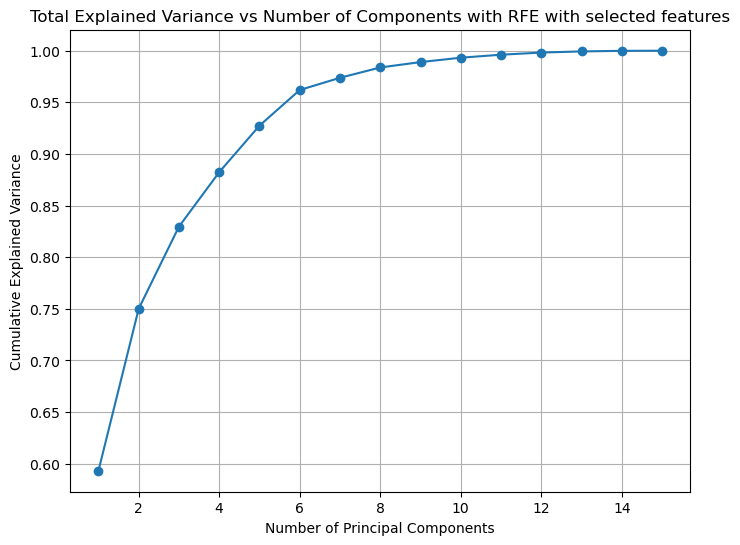

In [459]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Total Explained Variance vs Number of Components with RFE with selected features")
plt.grid(True)
plt.show()

In [460]:
breast_cancer_X_transformed = breast_cancer_X[removed_columns]
breast_cancer_X_transformed = StandardScaler().fit_transform(breast_cancer_X_transformed)
breast_cancer_X_transformed = pd.DataFrame(breast_cancer_X_transformed, columns=removed_columns)

pca = PCA(n_components=15)
pca.fit_transform(breast_cancer_X_transformed)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

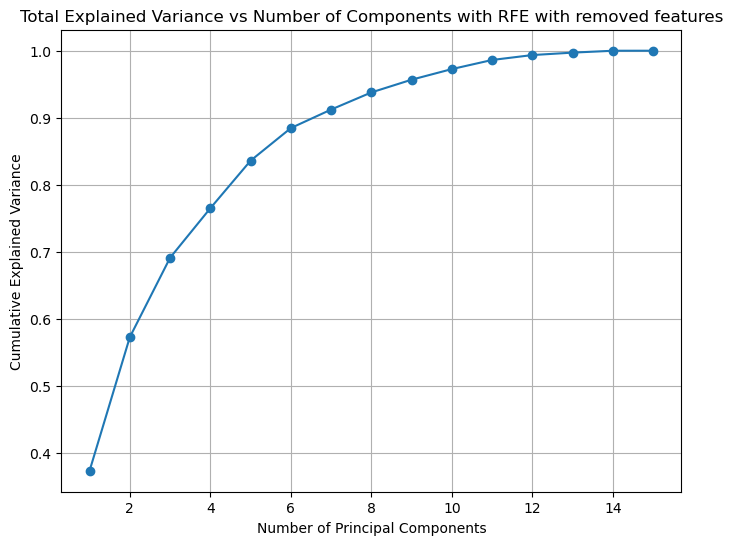

In [461]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Total Explained Variance vs Number of Components with RFE with removed features")
plt.grid(True)
plt.show()

In [ ]:
# Narysowałem trzy wykresy PCA – dla pełnych danych, dla 15 najlepszych cech oraz dla 15 najgorszych cech.
# Wyniki pokazują, że dla zestawu '15 najlepszych' potrzeba mniejszej liczby komponentów PCA,
# aby osiągnąć ten sam poziom skumulowanej wyjaśnionej wariancji, co oznacza, że informacja jest tam bardziej skoncentrowana.

# Wykres dla zestawu '15 najgorszych' jest gorszy, niż ten dla pełnego zestawu danych (ze wszystkimi kolumnami)